In [1]:
import os
import warnings
import numpy as np

import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten


I0000 00:00:1784212105.304072    6632 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784212105.421787    6632 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784212108.175482    6632 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


In [3]:
np.savez_compressed('mnist_preprocessed.npz', x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)


In [9]:
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization

num_classes = 10

model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),                      
    
    Dense(640, activation='relu'),  
    BatchNormalization(),
    Dropout(0.2),                  
    
    
    Dense(384, activation='relu'),  
    BatchNormalization(),
    Dropout(0.2),
    

    Dense(224, activation='relu'),  
    BatchNormalization(),
    Dropout(0.15),
    
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    
    
    Dense(num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
batch_size = 128
epochs = 20
history=model.fit(
    x_train, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    verbose=1, 
    validation_data=(x_test, y_test)
)

Epoch 1/20


W0000 00:00:1784213265.743211    6632 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9161 - loss: 0.2804 - val_accuracy: 0.9625 - val_loss: 0.1207
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9612 - loss: 0.1253 - val_accuracy: 0.9727 - val_loss: 0.0913
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9690 - loss: 0.0980 - val_accuracy: 0.9726 - val_loss: 0.0885
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9743 - loss: 0.0828 - val_accuracy: 0.9763 - val_loss: 0.0781
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9777 - loss: 0.0708 - val_accuracy: 0.9778 - val_loss: 0.0718
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9791 - loss: 0.0657 - val_accuracy: 0.9795 - val_loss: 0.0705
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9815 - loss: 0.0579 - val_accuracy: 0.9796 - val_loss: 0.0662
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9840 - loss: 0.0511 - val_accurac

In [11]:
model.save('mnist.h5')


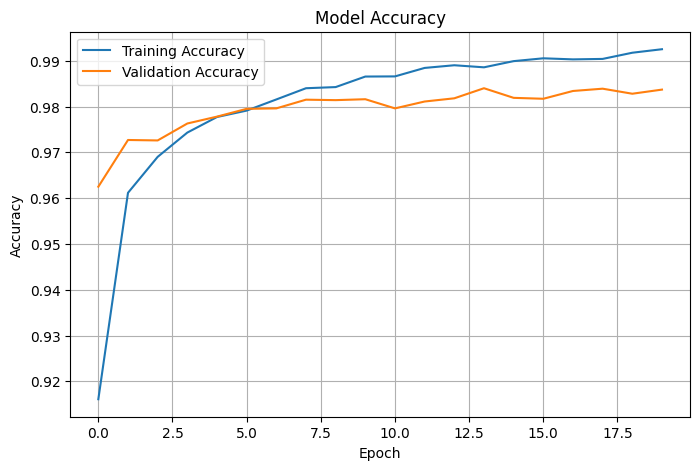

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

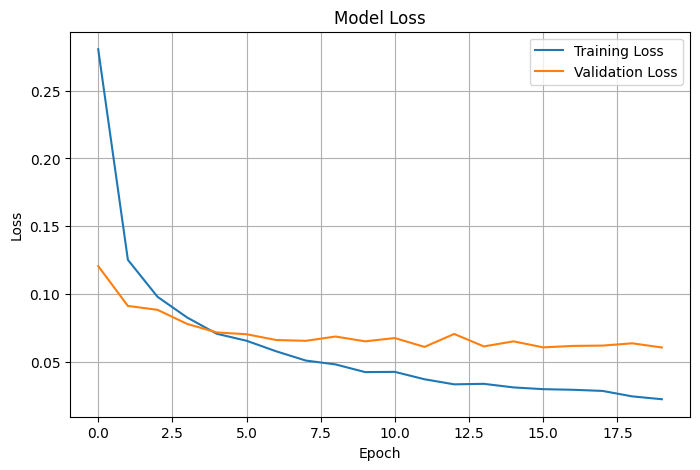

In [14]:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

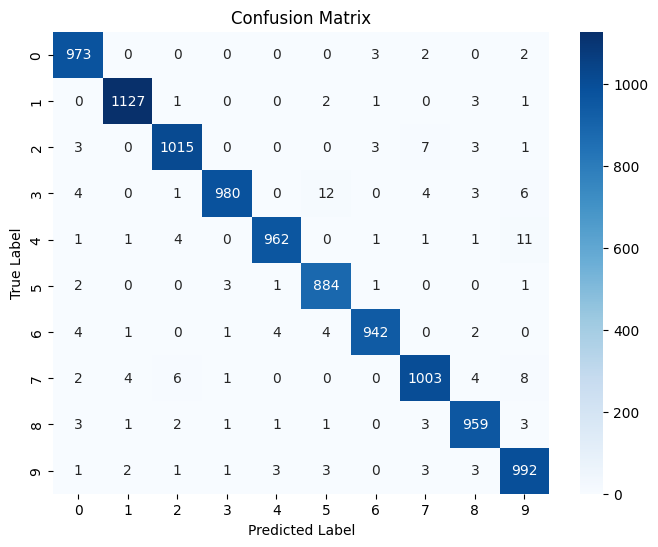

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


y_pred_prob=model.predict(x_test,verbose=0)
y_pred=np.argmax(y_pred_prob,axis=1)

y_true=np.argmax(y_test,axis=1) if len(y_test.shape)>1 else y_test

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues', xticklabels=range(10),yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true,y_pred,digits=6))

              precision    recall  f1-score   support

           0   0.979859  0.992857  0.986315       980
           1   0.992077  0.992952  0.992514      1135
           2   0.985437  0.983527  0.984481      1032
           3   0.992908  0.970297  0.981472      1010
           4   0.990731  0.979633  0.985151       982
           5   0.975717  0.991031  0.983315       892
           6   0.990536  0.983299  0.986904       958
           7   0.980450  0.975681  0.978059      1028
           8   0.980573  0.984600  0.982582       974
           9   0.967805  0.983152  0.975418      1009

    accuracy                       0.983700     10000
   macro avg   0.983609  0.983703  0.983621     10000
weighted avg   0.983774  0.983700  0.983703     10000

